# DỰ ÁN TỐT NGHIỆP: NHẬN DIỆN TÀI XẾ BUỒN NGỦ VỚI DEEP LSTM (SUST DATASET)
## NOTEBOOK: `test_model.ipynb` - KIỂM THỬ & ĐÁNH GIÁ TOÀN DIỆN MÔ HÌNH
---

### 1. Mục tiêu kiểm thử:
* Đánh giá hiệu năng của mô hình **Deep LSTM** đã được huấn luyện trong `datn4ni2.ipynb` trên tập dữ liệu kiểm thử / validation định dạng tensor `.pt` chuẩn.
* Đo lường toàn diện tất cả các thông số định lượng chuyên sâu cho bài toán an toàn giao thông và phân loại chuỗi thời gian:
  * **Độ chính xác tổng thể & cân bằng**: Overall Accuracy, Balanced Accuracy, Cross-Entropy Loss.
  * **Chỉ số phân loại chuyên sâu**: Precision, Recall (Sensitivity), Specificity (True Negative Rate), F1-Score, Matthews Correlation Coefficient (MCC), Cohen's Kappa.
  * **Chỉ số xác suất & đường cong**: ROC-AUC (Receiver Operating Characteristic), PR-AUC (Precision-Recall / Average Precision), Brier Score (Calibration error).
  * **Ma trận nhầm lẫn chi tiết (Confusion Matrix Breakdown)**: True Positive (TP), True Negative (TN), False Positive (FP - Báo động giả), False Negative (FN - Bỏ sót nguy hiểm), False Positive Rate (FPR), False Negative Rate (FNR), Negative Predictive Value (NPV).
  * **Tốc độ suy luận (Inference Speed)**: Latency (ms/mẫu), Throughput (video/s), Tốc độ khung hình tương đương (FPS).
  * **Khảo sát ngưỡng tối ưu (Threshold Tuning Analysis)**: Tối ưu hóa điểm cân bằng giữa bắt trúng buồn ngủ (Recall) và tránh báo động giả (Precision).
  * **Động học chuỗi thời gian (Temporal Dynamics)**: Phân tích đường cong xác suất buồn ngủ qua 120 khung hình ($t=1 \dots 120$).
  * **Phân tích lỗi (Error Analysis)**: Trích xuất các mẫu nhận diện sai có độ tự tin cao nhất để đề xuất hướng cải tiến.
  * **Xuất báo cáo định lượng**: Tự động xuất kết quả ra file `test_evaluation_report.json` và `test_predictions.csv` phục vụ báo cáo đồ án tốt nghiệp.


In [1]:
# ==============================================================================
# CELL 1: CÀI ĐẶT CÁC GÓI BỔ TRỢ & THIẾT LẬP MÔI TRƯỜNG (ENVIRONMENT SETUP)
# ==============================================================================
# !pip install -q seaborn scikit-learn matplotlib pandas tabulate

import os
import sys
import time
import json
import random
from pathlib import Path
from typing import Dict, List, Tuple, Optional, Any, Union

# Đảm bảo console Windows/Linux hiển thị chuẩn UTF-8
if hasattr(sys.stdout, "reconfigure"):
    sys.stdout.reconfigure(encoding="utf-8")
if hasattr(sys.stderr, "reconfigure"):
    sys.stderr.reconfigure(encoding="utf-8")

# Tối ưu hóa bộ nhớ đệm PyTorch GPU
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report,
    matthews_corrcoef,
    cohen_kappa_score,
    brier_score_loss,
    log_loss
)

# Cố định Seed ngẫu nhiên để đảm bảo 100% tái lập kết quả kiểm thử
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

seed_everything(42)

print("=" * 80)
print(f"[+] Python Version       : {sys.version.split()[0]}")
print(f"[+] PyTorch Version      : {torch.__version__}")
print(f"[+] CUDA Khả dụng        : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"[+] Thiết bị GPU         : {torch.cuda.get_device_name(0)}")
    vram_gb = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)
    print(f"[+] Dung lượng VRAM      : {vram_gb:.2f} GB")
print("=" * 80)


[+] Python Version       : 3.12.13
[+] PyTorch Version      : 2.13.0+cu126
[+] CUDA Khả dụng        : True
[+] Thiết bị GPU         : NVIDIA GeForce RTX 3050 Laptop GPU
[+] Dung lượng VRAM      : 4.00 GB


In [2]:
# ==============================================================================
# CELL 2: CẤU HÌNH KIỂM THỬ TẬP TRUNG (TEST CONFIGURATION)
# ==============================================================================
IS_KAGGLE = os.path.exists("/kaggle")
IS_COLAB = "google.colab" in sys.modules

class TestConfig:
    """Cấu hình tập trung cho quy trình kiểm thử và đánh giá mô hình Deep LSTM."""

    # 1. ĐƯỜNG DẪN CHECKPOINT MÔ HÌNH (.pth)
    # Tự động dò tìm checkpoint tốt nhất trên cả môi trường Local, Kaggle hoặc Colab
    possible_ckpts = [
        "lstm_experiment_results/checkpoints/best_lstm.pth",
        "checkpoints/best_lstm.pth",
        "/kaggle/working/checkpoints/best_lstm.pth",
        "/kaggle/input/lstm-sust-t4/best_lstm.pth",
        "lstm_experiment_results/checkpoints/last_lstm.pth",
        "checkpoints/last_lstm.pth",
    ]
    checkpoint_path: str = ""
    for p in possible_ckpts:
        if os.path.exists(p):
            checkpoint_path = p
            break
    if not checkpoint_path:
        checkpoint_path = "lstm_experiment_results/checkpoints/best_lstm.pth"
        # checkpoint_path = "lstm_experiment_results/checkpoints/last_lstm.pth"


    # 2. ĐƯỜNG DẪN TỆP DỮ LIỆU KIỂM THỬ TENSOR (.pt)
    # Tự động chọn file dữ liệu kiểm thử có sẵn
    possible_data = [
        "extracted_test_features_pt/features_VBDDD-dataset_train.pt",
        "extracted_features_pt/features_sust_val.pt",
        "/kaggle/input/datasets/nyvantran6634/sust4ni1/features_sust_val.pt",
        "/kaggle/input/sust4ni1/features_sust_val.pt",
        "extracted_features_pt/features_sust_train.pt",
    ]
    test_pt_path: str = ""
    for p in possible_data:
        if os.path.exists(p):
            test_pt_path = p
            break
    if not test_pt_path:
        test_pt_path = "extracted_features_pt/features_sust_val.pt"

    # 3. THƯ MỤC XUẤT KẾT QUẢ ĐÁNH GIÁ
    output_dir: str = "/kaggle/working/test_results" if IS_KAGGLE else "./evaluation_results1"
    os.makedirs(output_dir, exist_ok=True)

    # 4. CẤU HÌNH KIẾN TRÚC MÔ HÌNH (Khớp chuẩn 100% với datn4ni2.ipynb)
    seq_len: int = 120                      # Độ dài chuỗi thời gian (120 frames)
    cnn_neck_channels = (224, 448, 640)     # Số kênh 3 tầng đặc trưng (p3, p4, p5)
    total_feature_dim: int = 1312           # Tổng số kênh khi ghép nối (224 + 448 + 640 = 1312)
    input_dim: int = 512                    # Chiều vector sau Spatial Feature Adapter
    hidden_dim: int = 512                   # Số đơn vị ẩn trong mỗi lớp LSTM
    num_layers: int = 3                     # Số lớp LSTM sâu
    num_classes: int = 2                    # Phân loại nhị phân: 0 (Tỉnh táo), 1 (Buồn ngủ)
    spatial_fusion: str = "concat"          # Chiến lược kết hợp đặc trưng: concat
    adapter_dropout: float = 0.1            # Dropout sau Spatial Adapter
    dropout: float = 0.2                    # Dropout giữa các tầng LSTM

    # 5. THAM SỐ SUY LUẬN & ĐÁNH GIÁ
    batch_size: int = 64                    # Kích thước Batch đánh giá
    decision_threshold: float = 0.5         # Ngưỡng quyết định nhị phân mặc định
    device: str = "cuda:0" if torch.cuda.is_available() else "cpu"

    # 6. TÊN & NHÃN CÁC LỚP PHÂN LOẠI
    class_names: List[str] = ["Tỉnh táo (Alert)", "Buồn ngủ (Drowsy)"]
    class_labels: List[int] = [0, 1]

cfg = TestConfig()

print("=" * 80)
print(f"[+] Môi trường thực thi    : {'KAGGLE' if IS_KAGGLE else ('COLAB' if IS_COLAB else 'LOCAL PC')}")
print(f"[+] Thiết bị tính toán     : {cfg.device}")
print(f"[+] Checkpoint mô hình     : {cfg.checkpoint_path} (Tồn tại: {os.path.exists(cfg.checkpoint_path)})")
print(f"[+] Tệp dữ liệu kiểm thử   : {cfg.test_pt_path} (Tồn tại: {os.path.exists(cfg.test_pt_path)})")
print(f"[+] Thư mục lưu kết quả    : {cfg.output_dir}")
print(f"[+] Ngưỡng phân loại mặc định: {cfg.decision_threshold}")
print("=" * 80)


[+] Môi trường thực thi    : LOCAL PC
[+] Thiết bị tính toán     : cuda:0
[+] Checkpoint mô hình     : lstm_experiment_results/checkpoints/best_lstm.pth (Tồn tại: True)
[+] Tệp dữ liệu kiểm thử   : extracted_test_features_pt/features_VBDDD-dataset_train.pt (Tồn tại: True)
[+] Thư mục lưu kết quả    : ./evaluation_results1
[+] Ngưỡng phân loại mặc định: 0.5


In [3]:
# ==============================================================================
# CELL 3: KIẾN TRÚC MÔ HÌNH & HÀM NẠP CHECKPOINT (MODEL & WEIGHT LOADER)
# ==============================================================================
class SpatialFeatureAdapter(nn.Module):
    """
    Tiếp nhận 3 vector đặc trưng đã nén không gian (p3: 224, p4: 448, p5: 640),
    ghép nối thành vector 1312 chiều và chiếu tuyến tính về không gian 256 chiều.
    """
    def __init__(
        self,
        in_channels: Tuple[int, ...] = (224, 448, 640),
        out_dim: int = 256,
        fusion: str = "concat",
        dropout: float = 0.1
    ):
        super().__init__()
        self.fusion = fusion.lower()
        self.total_in_channels = sum(in_channels)
        self.out_dim = out_dim

        if self.fusion == "concat":
            self.projection = nn.Sequential(
                nn.Linear(self.total_in_channels, out_dim),
                nn.LayerNorm(out_dim),
                nn.ReLU(inplace=True)
            )
        elif self.fusion in ("sum", "mean"):
            self.projections = nn.ModuleList([
                nn.Sequential(
                    nn.Linear(c, out_dim),
                    nn.LayerNorm(out_dim),
                    nn.ReLU(inplace=True)
                ) for c in in_channels
            ])
        else:
            raise ValueError(f"Phương thức fusion không hỗ trợ: {fusion}")

        self.dropout = nn.Dropout(dropout) if dropout > 0.0 else nn.Identity()

    def forward(self, features: Union[Tuple[torch.Tensor, ...], List[torch.Tensor], torch.Tensor]) -> torch.Tensor:
        if isinstance(features, (tuple, list)):
            p3, p4, p5 = features
            if self.fusion == "concat":
                fused = torch.cat([p3, p4, p5], dim=-1) # [B, T, 1312]
                out = self.projection(fused)            # [B, T, 256]
            elif self.fusion == "sum":
                proj = [proj_layer(f) for proj_layer, f in zip(self.projections, [p3, p4, p5])]
                out = torch.stack(proj, dim=0).sum(dim=0)
            elif self.fusion == "mean":
                proj = [proj_layer(f) for proj_layer, f in zip(self.projections, [p3, p4, p5])]
                out = torch.stack(proj, dim=0).mean(dim=0)
        else:
            out = self.projection(features)
        return self.dropout(out)


class DeepLSTMClassifier(nn.Module):
    """
    Mô hình phân loại chuỗi thời gian Deep LSTM 3 lớp xếp chồng:
    Đầu vào: (p3, p4, p5) -> Spatial Adapter (256) -> LSTM (3 layers, 256 units) -> FC Head (2 classes).
    """
    def __init__(
        self,
        input_dim: int = 256,
        hidden_dim: int = 256,
        num_layers: int = 3,
        num_classes: int = 2,
        spatial_in_channels: Tuple[int, ...] = (224, 448, 640),
        fusion: str = "concat",
        adapter_dropout: float = 0.1,
        dropout: float = 0.2
    ):
        super().__init__()
        self.spatial_adapter = SpatialFeatureAdapter(
            in_channels=spatial_in_channels,
            out_dim=input_dim,
            fusion=fusion,
            dropout=adapter_dropout
        )
        self.lstm = nn.LSTM(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )
        self.fc_out = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(
        self,
        features: Union[Tuple[torch.Tensor, ...], List[torch.Tensor], torch.Tensor],
        return_sequence: bool = True
    ) -> torch.Tensor:
        x = self.spatial_adapter(features)       # [B, T, 256]
        lstm_out, _ = self.lstm(x)               # [B, T, hidden_dim]
        if return_sequence:
            logits = self.fc_out(lstm_out)       # [B, T, num_classes]
        else:
            logits = self.fc_out(lstm_out[:, -1, :]) # [B, num_classes]
        return logits


def load_model_for_evaluation(ckpt_path: str, device: str) -> Tuple[DeepLSTMClassifier, Dict[str, Any]]:
    """Nạp an toàn trọng số mô hình và metadata đã lưu từ checkpoint .pth."""
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Không tìm thấy tệp checkpoint tại: {ckpt_path}")
        
    print(f"[+] Đang nạp checkpoint từ: {ckpt_path}...")
    checkpoint = torch.load(ckpt_path, map_location=device)
    
    # Đọc cấu hình mô hình nếu được lưu trong checkpoint
    saved_cfg = checkpoint.get("config", {})
    input_dim = saved_cfg.get("input_dim", cfg.input_dim)
    hidden_dim = saved_cfg.get("hidden_dim", cfg.hidden_dim)
    num_layers = saved_cfg.get("num_layers", cfg.num_layers)
    num_classes = saved_cfg.get("num_classes", cfg.num_classes)
    
    model = DeepLSTMClassifier(
        input_dim=input_dim,
        hidden_dim=hidden_dim,
        num_layers=num_layers,
        num_classes=num_classes,
        spatial_in_channels=cfg.cnn_neck_channels,
        fusion=cfg.spatial_fusion,
        adapter_dropout=cfg.adapter_dropout,
        dropout=cfg.dropout
    ).to(device)
    
    # Nạp state_dict
    state_dict = checkpoint.get("model_state_dict", checkpoint)
    model.load_state_dict(state_dict)
    model.eval()
    
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    print(f"    - Nạp trọng số mô hình thành công!")
    print(f"    - Epoch lưu trữ            : {checkpoint.get('epoch', 'N/A')}")
    val_acc_val = checkpoint.get('val_acc', None)
    if val_acc_val is not None:
        print(f"    - Val Acc lúc huấn luyện   : {val_acc_val*100:.2f}%")
    f1_val = checkpoint.get('f1_score', None)
    if f1_val is not None:
        print(f"    - F1-Score lúc huấn luyện  : {f1_val:.4f}")
    print(f"    - Tổng số tham số mô hình  : {total_params:,} ({trainable_params:,} trainable)")
    
    metadata = {
        "epoch": checkpoint.get("epoch"),
        "val_acc": checkpoint.get("val_acc"),
        "f1_score": checkpoint.get("f1_score"),
        "total_params": total_params
    }
    return model, metadata

model, model_metadata = load_model_for_evaluation(cfg.checkpoint_path, cfg.device)


[+] Đang nạp checkpoint từ: lstm_experiment_results/checkpoints/best_lstm.pth...


D:\Users\tonda\anaconda3\envs\mylstm\Lib\site-packages\torch\_utils.py:108: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:40.)
  untyped_storage = torch.UntypedStorage(self.size(), device=device)


    - Nạp trọng số mô hình thành công!
    - Epoch lưu trữ            : 42
    - Val Acc lúc huấn luyện   : 80.96%
    - F1-Score lúc huấn luyện  : 0.7859
    - Tổng số tham số mô hình  : 6,978,050 (6,978,050 trainable)


In [4]:
# ==============================================================================
# CELL 4: NẠP TẬP DỮ LIỆU KIỂM THỬ ĐÃ ĐỊNH DẠNG SẴN (.PT)
# ==============================================================================
class PreloadedTensorDataset(Dataset):
    """
    Dataset nạp toàn bộ Tensor .pt vào RAM một lần duy nhất.
    Độ trễ I/O cực thấp (< 0.5s), tự động hỗ trợ cả float32 và float16.
    """
    def __init__(self, pt_path: str):
        super().__init__()
        path = Path(pt_path)
        if not path.exists():
            raise FileNotFoundError(f"Không tìm thấy file dữ liệu: {path.resolve()}")

        t0 = time.time()
        print(f"[+] Đang nạp dữ liệu kiểm thử từ: {path.resolve()}...")
        data = torch.load(str(path), map_location="cpu")

        # Ép kiểu float32 để đảm bảo tương thích tính toán trên mọi thiết bị
        self.p3 = data["p3"].float()       # [N, 120, 224]
        self.p4 = data["p4"].float()       # [N, 120, 448]
        self.p5 = data["p5"].float()       # [N, 120, 640]
        self.labels = data["labels"].long() # [N]
        self.video_ids = data.get("video_ids", [f"video_{i:04d}" for i in range(len(self.labels))])

        load_sec = time.time() - t0
        print(f"    - Thời gian nạp dữ liệu vào RAM : {load_sec:.2f}s")
        print(f"    - Tổng số video kiểm thử        : {len(self.labels):,}")
        
        count_alert = (self.labels == 0).sum().item()
        count_drowsy = (self.labels == 1).sum().item()
        total = len(self.labels)
        print(f"    - Tỉnh táo (Class 0)            : {count_alert:,} video ({count_alert/total*100:.2f}%)")
        print(f"    - Buồn ngủ (Class 1)            : {count_drowsy:,} video ({count_drowsy/total*100:.2f}%)")
        print(f"    - Tỷ lệ Buồn ngủ / Tỉnh táo     : {count_drowsy/max(count_alert, 1):.2f} : 1")
        print(f"    - Kích thước tensor p3          : {list(self.p3.shape)}")
        print(f"    - Kích thước tensor p4          : {list(self.p4.shape)}")
        print(f"    - Kích thước tensor p5          : {list(self.p5.shape)}")

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> Tuple[Tuple[torch.Tensor, torch.Tensor, torch.Tensor], torch.Tensor, str]:
        return (self.p3[idx], self.p4[idx], self.p5[idx]), self.labels[idx], self.video_ids[idx]

test_dataset = PreloadedTensorDataset(cfg.test_pt_path)
test_loader = DataLoader(
    test_dataset,
    batch_size=cfg.batch_size,
    shuffle=False,
    drop_last=False,
    pin_memory=True if "cuda" in cfg.device else False
)

print(f"[+] Khởi tạo DataLoader kiểm thử thành công: {len(test_dataset)} mẫu ({len(test_loader)} batches | Batch size: {cfg.batch_size})")


[+] Đang nạp dữ liệu kiểm thử từ: D:\Project\AI\myLSTM\extracted_test_features_pt\features_VBDDD-dataset_train.pt...
    - Thời gian nạp dữ liệu vào RAM : 1.33s
    - Tổng số video kiểm thử        : 558
    - Tỉnh táo (Class 0)            : 345 video (61.83%)
    - Buồn ngủ (Class 1)            : 213 video (38.17%)
    - Tỷ lệ Buồn ngủ / Tỉnh táo     : 0.62 : 1
    - Kích thước tensor p3          : [558, 120, 224]
    - Kích thước tensor p4          : [558, 120, 448]
    - Kích thước tensor p5          : [558, 120, 640]
[+] Khởi tạo DataLoader kiểm thử thành công: 558 mẫu (9 batches | Batch size: 64)


In [5]:
# ==============================================================================
# CELL 5: ENGINE SUY LUẬN & ĐO LƯỜNG TỐC ĐỘ (INFERENCE & LATENCY BENCHMARK)
# ==============================================================================
print("=" * 80)
print("[*] ĐANG THỰC THI SUY LUẬN TRÊN TOÀN BỘ TẬP KIỂM THỬ...")
print("=" * 80)

model.eval()

all_video_ids: List[str] = []
all_targets: List[int] = []

# Mảng lưu kết quả dự đoán video-level (khung hình cuối hoặc sequence-level)
all_logits_last: List[np.ndarray] = []
all_probs_drowsy: List[float] = []
all_preds_video: List[int] = []

# Mảng lưu xác suất theo từng frame chuỗi thời gian [N, 120]
all_probs_seq: List[np.ndarray] = []

# Đồng bộ GPU để đo lường thời gian chính xác nhất
if torch.cuda.is_available():
    torch.cuda.synchronize()
start_infer_time = time.time()

with torch.no_grad():
    for (p3, p4, p5), labels, v_ids in test_loader:
        p3 = p3.to(cfg.device, non_blocking=True)
        p4 = p4.to(cfg.device, non_blocking=True)
        p5 = p5.to(cfg.device, non_blocking=True)

        # Trích xuất logits chuỗi thời gian [B, 120, 2]
        logits_seq = model((p3, p4, p5), return_sequence=True)
        
        # Xác suất Softmax theo chuỗi [B, 120, 2] -> lấy lớp Buồn ngủ (1)
        probs_seq = torch.softmax(logits_seq, dim=-1)[:, :, 1]
        
        # Logits và xác suất tại khung hình quyết định cuối cùng (frame 120)
        logits_last = logits_seq[:, -1, :] # [B, 2]
        probs_drowsy = torch.softmax(logits_last, dim=-1)[:, 1] # [B]
        
        # Dự đoán theo ngưỡng quyết định
        preds_video = (probs_drowsy >= cfg.decision_threshold).long()

        # Thu thập dữ liệu về CPU
        all_logits_last.append(logits_last.cpu().numpy())
        all_probs_drowsy.extend(probs_drowsy.cpu().numpy().tolist())
        all_preds_video.extend(preds_video.cpu().numpy().tolist())
        all_probs_seq.append(probs_seq.cpu().numpy())
        all_targets.extend(labels.numpy().tolist())
        all_video_ids.extend(v_ids)

if torch.cuda.is_available():
    torch.cuda.synchronize()
total_infer_time = time.time() - start_infer_time

# Gom các mảng lại thành numpy arrays
all_targets = np.array(all_targets)
all_preds_video = np.array(all_preds_video)
all_probs_drowsy = np.array(all_probs_drowsy)
all_logits_last = np.concatenate(all_logits_last, axis=0)
all_probs_seq = np.concatenate(all_probs_seq, axis=0) # [N, 120]

total_samples = len(all_targets)
latency_ms_per_video = (total_infer_time / total_samples) * 1000
throughput_videos_sec = total_samples / total_infer_time
total_frames = total_samples * cfg.seq_len
equivalent_fps = total_frames / total_infer_time

print(f"[SUCCESS] Đã hoàn thành suy luận {total_samples} video trong {total_infer_time:.3f} giây!")
print("-" * 80)
print(f"[*] THỐNG KÊ HIỆU NĂNG TỐC ĐỘ (INFERENCE BENCHMARK):")
print(f"    - Tổng thời gian suy luận  : {total_infer_time:.4f} s")
print(f"    - Độ trễ mỗi video (Latency): {latency_ms_per_video:.2f} ms / video ({cfg.seq_len} frames)")
print(f"    - Thông lượng (Throughput) : {throughput_videos_sec:.2f} video / giây")
print(f"    - Tốc độ xử lý tương đương : {equivalent_fps:.2f} FPS (Khung hình / giây)")
print("=" * 80)


[*] ĐANG THỰC THI SUY LUẬN TRÊN TOÀN BỘ TẬP KIỂM THỬ...
[SUCCESS] Đã hoàn thành suy luận 558 video trong 5.388 giây!
--------------------------------------------------------------------------------
[*] THỐNG KÊ HIỆU NĂNG TỐC ĐỘ (INFERENCE BENCHMARK):
    - Tổng thời gian suy luận  : 5.3884 s
    - Độ trễ mỗi video (Latency): 9.66 ms / video (120 frames)
    - Thông lượng (Throughput) : 103.56 video / giây
    - Tốc độ xử lý tương đương : 12426.79 FPS (Khung hình / giây)


In [6]:
# ==============================================================================
# CELL 6: BẢNG TỔNG HỢP TẤT CẢ CÁC THÔNG SỐ ĐỊNH LƯỢNG (EXECUTIVE METRICS REPORT)
# ==============================================================================
# 1. Tính toán Ma trận nhầm lẫn
cm = confusion_matrix(all_targets, all_preds_video)
tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (0, 0, 0, 0)

# 2. Các chỉ số phân loại cơ bản
acc = accuracy_score(all_targets, all_preds_video)
bal_acc = balanced_accuracy_score(all_targets, all_preds_video)
prec_macro = precision_score(all_targets, all_preds_video, average="macro", zero_division=0)
rec_macro  = recall_score(all_targets, all_preds_video, average="macro", zero_division=0)
f1_macro   = f1_score(all_targets, all_preds_video, average="macro", zero_division=0)

prec_drowsy = precision_score(all_targets, all_preds_video, pos_label=1, zero_division=0)
rec_drowsy  = recall_score(all_targets, all_preds_video, pos_label=1, zero_division=0)
f1_drowsy   = f1_score(all_targets, all_preds_video, pos_label=1, zero_division=0)

prec_alert = precision_score(all_targets, all_preds_video, pos_label=0, zero_division=0)
rec_alert  = recall_score(all_targets, all_preds_video, pos_label=0, zero_division=0)
f1_alert   = f1_score(all_targets, all_preds_video, pos_label=0, zero_division=0)

# 3. Các chỉ số nâng cao chuyên biệt cho An toàn Lái xe & Y tế
# Sensitivity (True Positive Rate) & Specificity (True Negative Rate)
sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0 # Độ nhạy bắt trúng buồn ngủ
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0 # Độ đặc hiệu phát hiện tỉnh táo
fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0         # Tỷ lệ báo động giả (False Alarm Rate)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0         # Tỷ lệ bỏ sót nguy hiểm (Miss Rate)
npv = tn / (tn + fn) if (tn + fn) > 0 else 0.0         # Giá trị dự báo âm tính

# Matthews Correlation Coefficient (MCC) & Cohen's Kappa
mcc = matthews_corrcoef(all_targets, all_preds_video)
kappa = cohen_kappa_score(all_targets, all_preds_video)

# Cross-Entropy / Log Loss & Brier Score Loss
ce_loss = log_loss(all_targets, np.stack([1 - all_probs_drowsy, all_probs_drowsy], axis=-1))
brier = brier_score_loss(all_targets, all_probs_drowsy)

# ROC-AUC & PR-AUC (Average Precision)
roc_auc = roc_auc_score(all_targets, all_probs_drowsy)
pr_auc = average_precision_score(all_targets, all_probs_drowsy)

# ------------------------------------------------------------------------------
# TRÌNH BÀY BẢNG TỔNG HỢP CHỈ SỐ TOÀN DIỆN (DATAFRAME)
# ------------------------------------------------------------------------------
summary_metrics = {
    "Nhóm Thông Số": [
        "1. Hiệu năng Tổng thể", "1. Hiệu năng Tổng thể", "1. Hiệu năng Tổng thể", "1. Hiệu năng Tổng thể",
        "2. Điểm F1 & Cân bằng", "2. Điểm F1 & Cân bằng", "2. Điểm F1 & Cân bằng", "2. Điểm F1 & Cân bằng",
        "3. Tương quan & Thống kê", "3. Tương quan & Thống kê",
        "4. Phân tích Rủi ro An toàn", "4. Phân tích Rủi ro An toàn", "4. Phân tích Rủi ro An toàn", "4. Phân tích Rủi ro An toàn",
        "5. Tốc độ & Tài nguyên", "5. Tốc độ & Tài nguyên"
    ],
    "Tên Chỉ Số (Metric)": [
        "Độ chính xác (Overall Accuracy)",
        "Độ chính xác cân bằng (Balanced Accuracy)",
        "Cross-Entropy Loss (Log Loss)",
        "Brier Score (Calibration Error)",
        "F1-Score Lớp Buồn ngủ (Class 1)",
        "F1-Score Lớp Tỉnh táo (Class 0)",
        "Macro F1-Score",
        "Diện tích ROC-AUC",
        "Hệ số tương quan Matthews (MCC)",
        "Hệ số thống nhất Cohen's Kappa",
        "Độ nhạy bắt trúng (Recall / Sensitivity)",
        "Độ đặc hiệu (Specificity / TNR)",
        "Tỷ lệ báo động giả (False Positive Rate)",
        "Tỷ lệ bỏ sót nguy hiểm (False Negative Rate)",
        "Độ trễ xử lý (Latency / Video)",
        "Tốc độ khung hình tương đương (FPS)"
    ],
    "Giá Trị Định Lượng": [
        f"{acc * 100:.2f} %",
        f"{bal_acc * 100:.2f} %",
        f"{ce_loss:.4f}",
        f"{brier:.4f}",
        f"{f1_drowsy:.4f} ({f1_drowsy * 100:.2f}%)",
        f"{f1_alert:.4f} ({f1_alert * 100:.2f}%)",
        f"{f1_macro:.4f} ({f1_macro * 100:.2f}%)",
        f"{roc_auc:.4f} ({roc_auc * 100:.2f}%)",
        f"{mcc:.4f}",
        f"{kappa:.4f}",
        f"{sensitivity * 100:.2f} %",
        f"{specificity * 100:.2f} %",
        f"{fpr * 100:.2f} %",
        f"{fnr * 100:.2f} %",
        f"{latency_ms_per_video:.2f} ms",
        f"{equivalent_fps:.2f} FPS"
    ],
    "Ý Nghĩa Thực Tiễn": [
        "Tỷ lệ dự đoán đúng trên toàn bộ tập dữ liệu",
        "Trung bình độ chính xác trên từng lớp (tránh ảo giác mất cân bằng)",
        "Độ mất mát entropy chéo đo lường độ tự tin dự đoán",
        "Sai số toàn phương trung bình giữa xác suất dự đoán và nhãn thực tế",
        "Chỉ số hài hòa giữa Precision và Recall cho lớp quan trọng Buồn ngủ",
        "Chỉ số đo lường khả năng nhận biết tài xế bình thường",
        "Đánh giá cân bằng giữa hai lớp không thiên vị",
        "Khả năng phân biệt giữa tài xế buồn ngủ và tỉnh táo",
        "Độ đo tương quan nhị phân chuẩn xác nhất (-1 đến +1)",
        "Mức độ đồng thuận ngoài ngẫu nhiên giữa mô hình và thực tế",
        "Khả năng phát hiện đúng khi tài xế thực sự buồn ngủ (CỰC KỲ QUAN TRỌNG)",
        "Khả năng nhận diện chính xác khi tài xế hoàn toàn tỉnh táo",
        "Tỷ lệ tài xế tỉnh táo bị cảnh báo nhầm thành buồn ngủ (Gây phiền toái)",
        "Tỷ lệ tài xế ngủ gật mà hệ thống KHÔNG phát hiện (NGUY HIỂM NHẤT)",
        "Thời gian mô hình xử lý xong một chuỗi 120 frames video",
        "Khả năng đáp ứng thời gian thực (Real-time Requirement >= 30 FPS)"
    ]
}

df_summary = pd.DataFrame(summary_metrics)
print("\n" + "=" * 95)
print("             BẢNG TỔNG HỢP TẤT CẢ CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH (EXECUTIVE REPORT)")
print("=" * 95)
display(df_summary)

# ------------------------------------------------------------------------------
# BÁO CÁO PHÂN LOẠI CHI TIẾT TỪNG LỚP (CLASSIFICATION REPORT TABLE)
# ------------------------------------------------------------------------------
report_dict = classification_report(
    all_targets, all_preds_video,
    target_names=cfg.class_names,
    output_dict=True,
    zero_division=0
)
df_class_report = pd.DataFrame(report_dict).transpose()
print("\n" + "=" * 80)
print("             BÁO CÁO PHÂN LOẠI CHI TIẾT (DETAILED CLASSIFICATION REPORT)")
print("=" * 80)
display(df_class_report)

# ------------------------------------------------------------------------------
# THỐNG KÊ MA TRẬN NHẦM LẪN CHI TIẾT (CONFUSION MATRIX BREAKDOWN)
# ------------------------------------------------------------------------------
print("\n" + "=" * 80)
print("             CHI TIẾT MA TRẬN NHẦM LẪN (CONFUSION MATRIX BREAKDOWN)")
print("=" * 80)
print(f"[*] True Negative  (TN - Tỉnh táo đúng)    : {tn:4d} mẫu ({tn/total_samples*100:.2f}%)")
print(f"[*] False Positive (FP - Báo động giả)     : {fp:4d} mẫu ({fp/total_samples*100:.2f}%) [Báo nhầm]")
print(f"[*] False Negative (FN - Bỏ sót buồn ngủ)  : {fn:4d} mẫu ({fn/total_samples*100:.2f}%) [CỰC NGUY HIỂM]")
print(f"[*] True Positive  (TP - Bắt trúng buồn ngủ): {tp:4d} mẫu ({tp/total_samples*100:.2f}%)")
print("-" * 80)
print(f"[*] Tổng số mẫu video đánh giá             : {total_samples:4d} mẫu (100.00%)")
print("=" * 80)



             BẢNG TỔNG HỢP TẤT CẢ CÁC CHỈ SỐ ĐÁNH GIÁ MÔ HÌNH (EXECUTIVE REPORT)


,Nhóm Thông Số,Tên Chỉ Số (Metric),Giá Trị Định Lượng,Ý Nghĩa Thực Tiễn
0,1. Hiệu năng Tổng thể,Độ chính xác (Overall Accuracy),61.83 %,Tỷ lệ dự đoán đúng trên toàn bộ tập dữ liệu
1,1. Hiệu năng Tổng thể,Độ chính xác cân bằng (Balanced Accuracy),50.00 %,Trung bình độ chính xác trên từng lớp (tránh ả...
2,1. Hiệu năng Tổng thể,Cross-Entropy Loss (Log Loss),0.7610,Độ mất mát entropy chéo đo lường độ tự tin dự ...
3,1. Hiệu năng Tổng thể,Brier Score (Calibration Error),0.2697,Sai số toàn phương trung bình giữa xác suất dự...
4,2. Điểm F1 & Cân bằng,F1-Score Lớp Buồn ngủ (Class 1),0.0000 (0.00%),Chỉ số hài hòa giữa Precision và Recall cho lớ...
5,2. Điểm F1 & Cân bằng,F1-Score Lớp Tỉnh táo (Class 0),0.7641 (76.41%),Chỉ số đo lường khả năng nhận biết tài xế bình...
6,2. Điểm F1 & Cân bằng,Macro F1-Score,0.3821 (38.21%),Đánh giá cân bằng giữa hai lớp không thiên vị
7,2. Điểm F1 & Cân bằng,Diện tích ROC-AUC,0.4662 (46.62%),Khả năng phân biệt giữa tài xế buồn ngủ và tỉn...
8,3. Tương quan & Thống kê,Hệ số tương quan Matthews (MCC),0.0000,Độ đo tương quan nhị phân chuẩn xác nhất (-1 đ...
9,3. Tương quan & Thống kê,Hệ số thống nhất Cohen's Kappa,0.0000,Mức độ đồng thuận ngoài ngẫu nhiên giữa mô hìn...



             BÁO CÁO PHÂN LOẠI CHI TIẾT (DETAILED CLASSIFICATION REPORT)


,precision,recall,f1-score,support
Tỉnh táo (Alert),0.61828,1.00000,0.76412,345.00000
Buồn ngủ (Drowsy),0.00000,0.00000,0.00000,213.00000
accuracy,0.61828,0.61828,0.61828,0.61828
macro avg,0.30914,0.50000,0.38206,558.00000
weighted avg,0.38227,0.61828,0.47244,558.00000



             CHI TIẾT MA TRẬN NHẦM LẪN (CONFUSION MATRIX BREAKDOWN)
[*] True Negative  (TN - Tỉnh táo đúng)    :  345 mẫu (61.83%)
[*] False Positive (FP - Báo động giả)     :    0 mẫu (0.00%) [Báo nhầm]
[*] False Negative (FN - Bỏ sót buồn ngủ)  :  213 mẫu (38.17%) [CỰC NGUY HIỂM]
[*] True Positive  (TP - Bắt trúng buồn ngủ):    0 mẫu (0.00%)
--------------------------------------------------------------------------------
[*] Tổng số mẫu video đánh giá             :  558 mẫu (100.00%)


[+] Đã lưu biểu đồ tổng quan đánh giá vào: ./evaluation_results1\evaluation_summary_charts.png


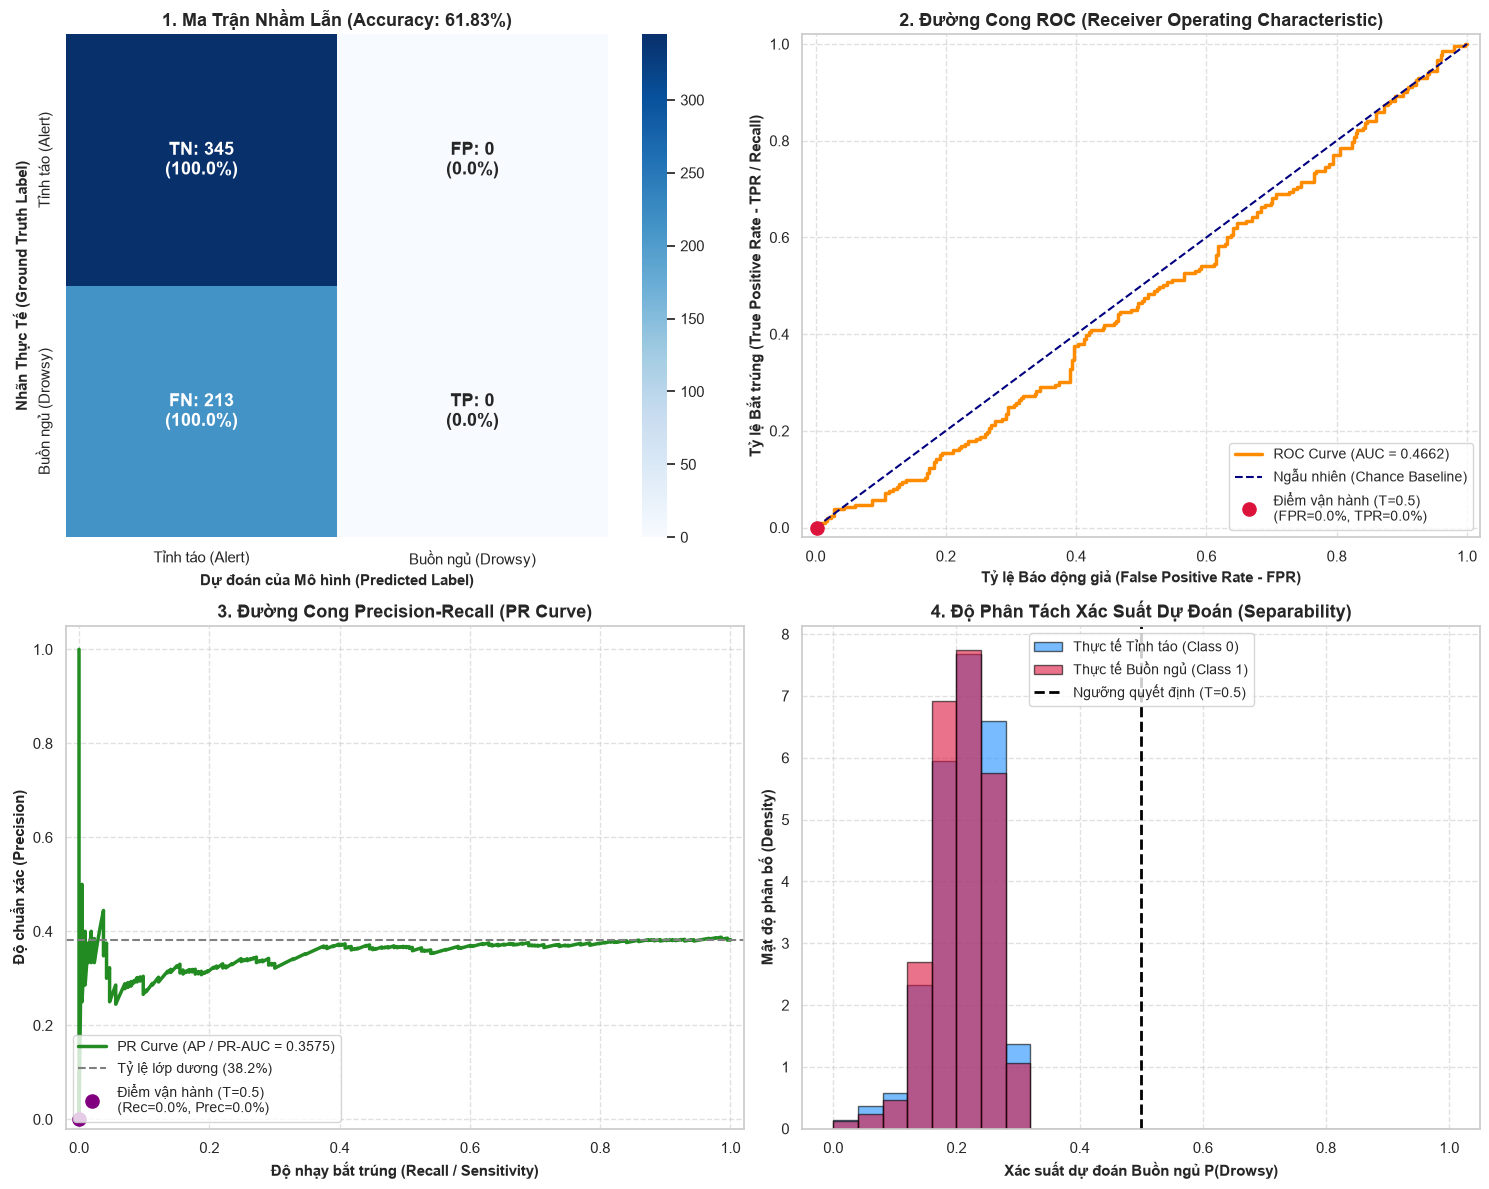

In [7]:
# ==============================================================================
# CELL 7: TRỰC QUAN HÓA ĐỒ HỌA TOÀN DIỆN (COMPREHENSIVE VISUALIZATIONS)
# ==============================================================================
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 10

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# ------------------------------------------------------------------------------
# 1. MA TRẬN NHẦM LẪN (CONFUSION MATRIX HEATMAP)
# ------------------------------------------------------------------------------
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
annot_labels = np.array([
    [f"TN: {tn}\n({cm_norm[0,0]*100:.1f}%)", f"FP: {fp}\n({cm_norm[0,1]*100:.1f}%)"],
    [f"FN: {fn}\n({cm_norm[1,0]*100:.1f}%)", f"TP: {tp}\n({cm_norm[1,1]*100:.1f}%)"]
])

sns.heatmap(
    cm, annot=annot_labels, fmt="", cmap="Blues", cbar=True,
    xticklabels=cfg.class_names, yticklabels=cfg.class_names,
    annot_kws={"fontsize": 13, "fontweight": "bold"}, ax=axes[0, 0]
)
axes[0, 0].set_title(f"1. Ma Trận Nhầm Lẫn (Accuracy: {acc*100:.2f}%)", fontsize=13, fontweight="bold")
axes[0, 0].set_xlabel("Dự đoán của Mô hình (Predicted Label)", fontsize=11, fontweight="bold")
axes[0, 0].set_ylabel("Nhãn Thực Tế (Ground Truth Label)", fontsize=11, fontweight="bold")

# ------------------------------------------------------------------------------
# 2. ĐƯỜNG CONG ĐẶC TRƯNG HOẠT ĐỘNG THU NHẬN (ROC CURVE)
# ------------------------------------------------------------------------------
fpr_curve, tpr_curve, roc_thresholds = roc_curve(all_targets, all_probs_drowsy)
axes[0, 1].plot(fpr_curve, tpr_curve, color="darkorange", lw=2.5, label=f"ROC Curve (AUC = {roc_auc:.4f})")
axes[0, 1].plot([0, 1], [0, 1], color="navy", lw=1.5, linestyle="--", label="Ngẫu nhiên (Chance Baseline)")

# Đánh dấu điểm hoạt động tại ngưỡng mặc định (T = cfg.decision_threshold)
default_idx = np.argmin(np.abs(roc_thresholds - cfg.decision_threshold))
axes[0, 1].scatter(
    [fpr_curve[default_idx]], [tpr_curve[default_idx]],
    color="crimson", s=90, zorder=5,
    label=f"Điểm vận hành (T={cfg.decision_threshold})\n(FPR={fpr*100:.1f}%, TPR={sensitivity*100:.1f}%)"
)

axes[0, 1].set_xlim([-0.02, 1.02])
axes[0, 1].set_ylim([-0.02, 1.02])
axes[0, 1].set_xlabel("Tỷ lệ Báo động giả (False Positive Rate - FPR)", fontsize=11, fontweight="bold")
axes[0, 1].set_ylabel("Tỷ lệ Bắt trúng (True Positive Rate - TPR / Recall)", fontsize=11, fontweight="bold")
axes[0, 1].set_title("2. Đường Cong ROC (Receiver Operating Characteristic)", fontsize=13, fontweight="bold")
axes[0, 1].legend(loc="lower right", fontsize=10, frameon=True)
axes[0, 1].grid(True, linestyle="--", alpha=0.6)

# ------------------------------------------------------------------------------
# 3. ĐƯỜNG CONG PRECISION-RECALL (PR CURVE)
# ------------------------------------------------------------------------------
prec_curve, rec_curve, pr_thresholds = precision_recall_curve(all_targets, all_probs_drowsy)
positive_ratio = (all_targets == 1).mean()

axes[1, 0].plot(rec_curve, prec_curve, color="forestgreen", lw=2.5, label=f"PR Curve (AP / PR-AUC = {pr_auc:.4f})")
axes[1, 0].axhline(y=positive_ratio, color="gray", linestyle="--", lw=1.5, label=f"Tỷ lệ lớp dương ({positive_ratio*100:.1f}%)")

# Đánh dấu điểm hoạt động
axes[1, 0].scatter(
    [sensitivity], [prec_drowsy],
    color="purple", s=90, zorder=5,
    label=f"Điểm vận hành (T={cfg.decision_threshold})\n(Rec={sensitivity*100:.1f}%, Prec={prec_drowsy*100:.1f}%)"
)

axes[1, 0].set_xlim([-0.02, 1.02])
axes[1, 0].set_ylim([-0.02, 1.05])
axes[1, 0].set_xlabel("Độ nhạy bắt trúng (Recall / Sensitivity)", fontsize=11, fontweight="bold")
axes[1, 0].set_ylabel("Độ chuẩn xác (Precision)", fontsize=11, fontweight="bold")
axes[1, 0].set_title("3. Đường Cong Precision-Recall (PR Curve)", fontsize=13, fontweight="bold")
axes[1, 0].legend(loc="lower left", fontsize=10, frameon=True)
axes[1, 0].grid(True, linestyle="--", alpha=0.6)

# ------------------------------------------------------------------------------
# 4. PHÂN BỐ XÁC SUẤT DỰ ĐOÁN (SEPARABILITY HISTOGRAM)
# ------------------------------------------------------------------------------
probs_alert = all_probs_drowsy[all_targets == 0]
probs_drowsy = all_probs_drowsy[all_targets == 1]

bins = np.linspace(0, 1, 26)
axes[1, 1].hist(probs_alert, bins=bins, alpha=0.6, color="dodgerblue", edgecolor="black", label="Thực tế Tỉnh táo (Class 0)", density=True)
axes[1, 1].hist(probs_drowsy, bins=bins, alpha=0.6, color="crimson", edgecolor="black", label="Thực tế Buồn ngủ (Class 1)", density=True)
axes[1, 1].axvline(x=cfg.decision_threshold, color="black", linestyle="--", lw=2, label=f"Ngưỡng quyết định (T={cfg.decision_threshold})")

axes[1, 1].set_xlabel("Xác suất dự đoán Buồn ngủ P(Drowsy)", fontsize=11, fontweight="bold")
axes[1, 1].set_ylabel("Mật độ phân bố (Density)", fontsize=11, fontweight="bold")
axes[1, 1].set_title("4. Độ Phân Tách Xác Suất Dự Đoán (Separability)", fontsize=13, fontweight="bold")
axes[1, 1].legend(loc="upper center", fontsize=10, frameon=True)
axes[1, 1].grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
eval_plot_path = os.path.join(cfg.output_dir, "evaluation_summary_charts.png")
plt.savefig(eval_plot_path, dpi=300, bbox_inches="tight")
print(f"[+] Đã lưu biểu đồ tổng quan đánh giá vào: {eval_plot_path}")
plt.show()


[+] Đã lưu biểu đồ khảo sát ngưỡng vào: ./evaluation_results1\threshold_tuning_analysis.png


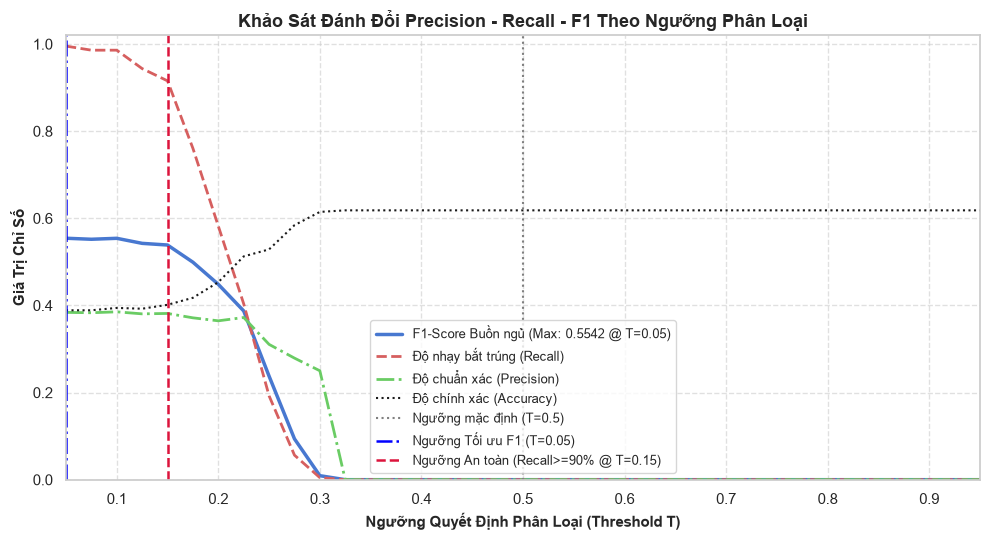

KHUYẾN NGHỊ LỰA CHỌN NGƯỠNG PHÂN LOẠI CHO THỰC TẾ:
1. Cấu hình Cân bằng Tối ưu (Best F1-Score): Ngưỡng T = 0.05
   -> Precision: 38.41% | Recall: 99.53% | F1: 0.5542
2. Cấu hình Ưu tiên An toàn Giao thông (Safety-First): Ngưỡng T = 0.15
   -> Precision: 38.16% | Recall: 91.55% | F1: 0.5387
   [Ý nghĩa]: Hạ ngưỡng giúp phát hiện >= 90% các tình huống buồn ngủ nguy hiểm!


In [8]:
# ==============================================================================
# CELL 8: KHẢO SÁT NGƯỠNG PHÂN LOẠI TỐI ƯU (DECISION THRESHOLD TUNING)
# ==============================================================================
threshold_scan = np.linspace(0.05, 0.95, 37)
t_precisions, t_recalls, t_f1s, t_accuracies, t_bal_accs = [], [], [], [], []

best_f1_score = -1.0
best_f1_threshold = 0.5

# Tìm ngưỡng an toàn giao thông (Safety-First Threshold) đảm bảo Recall >= 90%
safety_threshold = None

for t in threshold_scan:
    preds_t = (all_probs_drowsy >= t).astype(int)
    p = precision_score(all_targets, preds_t, pos_label=1, zero_division=0)
    r = recall_score(all_targets, preds_t, pos_label=1, zero_division=0)
    f = f1_score(all_targets, preds_t, pos_label=1, zero_division=0)
    a = accuracy_score(all_targets, preds_t)
    ba = balanced_accuracy_score(all_targets, preds_t)
    
    t_precisions.append(p)
    t_recalls.append(r)
    t_f1s.append(f)
    t_accuracies.append(a)
    t_bal_accs.append(ba)

    if f > best_f1_score:
        best_f1_score = f
        best_f1_threshold = t
        
    if r >= 0.90:
        safety_threshold = t

# Vẽ đồ thị Khảo sát Ngưỡng
fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(threshold_scan, t_f1s, "b-", lw=2.5, label=f"F1-Score Buồn ngủ (Max: {best_f1_score:.4f} @ T={best_f1_threshold:.2f})")
ax.plot(threshold_scan, t_recalls, "r--", lw=2, label="Độ nhạy bắt trúng (Recall)")
ax.plot(threshold_scan, t_precisions, "g-.", lw=2, label="Độ chuẩn xác (Precision)")
ax.plot(threshold_scan, t_accuracies, "k:", lw=1.5, label="Độ chính xác (Accuracy)")

# Đánh dấu các ngưỡng đặc biệt
ax.axvline(x=cfg.decision_threshold, color="gray", linestyle=":", lw=1.5, label=f"Ngưỡng mặc định (T={cfg.decision_threshold})")
ax.axvline(x=best_f1_threshold, color="blue", linestyle="-.", lw=1.8, label=f"Ngưỡng Tối ưu F1 (T={best_f1_threshold:.2f})")
if safety_threshold is not None:
    ax.axvline(x=safety_threshold, color="crimson", linestyle="--", lw=1.8, label=f"Ngưỡng An toàn (Recall>=90% @ T={safety_threshold:.2f})")

ax.set_title("Khảo Sát Đánh Đổi Precision - Recall - F1 Theo Ngưỡng Phân Loại", fontsize=13, fontweight="bold")
ax.set_xlabel("Ngưỡng Quyết Định Phân Loại (Threshold T)", fontsize=11, fontweight="bold")
ax.set_ylabel("Giá Trị Chỉ Số", fontsize=11, fontweight="bold")
ax.set_xlim([0.05, 0.95])
ax.set_ylim([0.0, 1.02])
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(loc="lower center", fontsize=9.5, frameon=True)
plt.tight_layout()

threshold_chart_path = os.path.join(cfg.output_dir, "threshold_tuning_analysis.png")
plt.savefig(threshold_chart_path, dpi=300, bbox_inches="tight")
print(f"[+] Đã lưu biểu đồ khảo sát ngưỡng vào: {threshold_chart_path}")
plt.show()

print("=" * 80)
print("KHUYẾN NGHỊ LỰA CHỌN NGƯỠNG PHÂN LOẠI CHO THỰC TẾ:")
print(f"1. Cấu hình Cân bằng Tối ưu (Best F1-Score): Ngưỡng T = {best_f1_threshold:.2f}")
preds_opt_f1 = (all_probs_drowsy >= best_f1_threshold).astype(int)
print(f"   -> Precision: {precision_score(all_targets, preds_opt_f1, pos_label=1)*100:.2f}% | "
      f"Recall: {recall_score(all_targets, preds_opt_f1, pos_label=1)*100:.2f}% | "
      f"F1: {f1_score(all_targets, preds_opt_f1, pos_label=1):.4f}")

if safety_threshold is not None:
    print(f"2. Cấu hình Ưu tiên An toàn Giao thông (Safety-First): Ngưỡng T = {safety_threshold:.2f}")
    preds_safe = (all_probs_drowsy >= safety_threshold).astype(int)
    print(f"   -> Precision: {precision_score(all_targets, preds_safe, pos_label=1)*100:.2f}% | "
          f"Recall: {recall_score(all_targets, preds_safe, pos_label=1)*100:.2f}% | "
          f"F1: {f1_score(all_targets, preds_safe, pos_label=1):.4f}")
    print("   [Ý nghĩa]: Hạ ngưỡng giúp phát hiện >= 90% các tình huống buồn ngủ nguy hiểm!")
print("=" * 80)


[+] Đã lưu biểu đồ phân tích chuỗi thời gian vào: ./evaluation_results1\temporal_sequence_dynamics.png


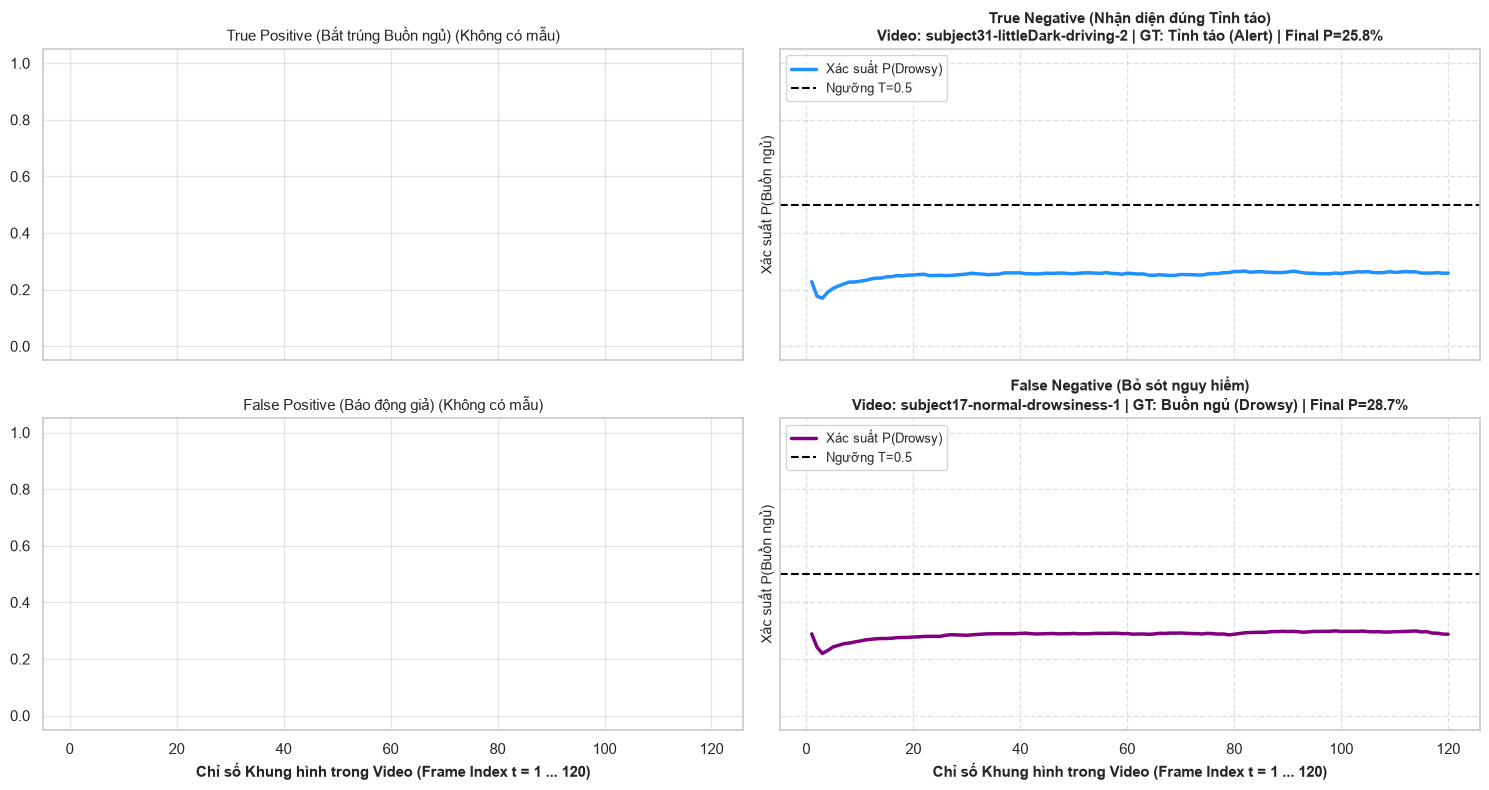

In [9]:
# ==============================================================================
# CELL 9: PHÂN TÍCH DIỄN BIẾN CHUỖI THỜI GIAN 120 FRAMES (TEMPORAL DEEP DIVE)
# ==============================================================================
# Chọn 4 mẫu đại diện để phân tích diễn biến:
# 1. True Positive (Bắt trúng Buồn ngủ)
# 2. True Negative (Nhận diện đúng Tỉnh táo)
# 3. False Positive (Báo nhầm Tỉnh táo thành Buồn ngủ)
# 4. False Negative (Bỏ sót Buồn ngủ)

idx_tp = np.where((all_targets == 1) & (all_preds_video == 1))[0]
idx_tn = np.where((all_targets == 0) & (all_preds_video == 0))[0]
idx_fp = np.where((all_targets == 0) & (all_preds_video == 1))[0]
idx_fn = np.where((all_targets == 1) & (all_preds_video == 0))[0]

cases = [
    ("True Positive (Bắt trúng Buồn ngủ)", idx_tp[0] if len(idx_tp) > 0 else None, "crimson"),
    ("True Negative (Nhận diện đúng Tỉnh táo)", idx_tn[0] if len(idx_tn) > 0 else None, "dodgerblue"),
    ("False Positive (Báo động giả)", idx_fp[0] if len(idx_fp) > 0 else None, "darkorange"),
    ("False Negative (Bỏ sót nguy hiểm)", idx_fn[0] if len(idx_fn) > 0 else None, "purple")
]

fig, axes = plt.subplots(2, 2, figsize=(15, 8), sharex=True, sharey=True)
axes = axes.flatten()

frames = np.arange(1, cfg.seq_len + 1)

for ax, (title, idx, color) in zip(axes, cases):
    if idx is not None:
        prob_curve = all_probs_seq[idx] # 120 frames
        vid_id = all_video_ids[idx]
        gt_label = cfg.class_names[all_targets[idx]]
        final_prob = all_probs_drowsy[idx]
        
        ax.plot(frames, prob_curve, color=color, lw=2.5, label="Xác suất P(Drowsy)")
        ax.axhline(y=cfg.decision_threshold, color="black", linestyle="--", lw=1.5, label=f"Ngưỡng T={cfg.decision_threshold}")
        ax.fill_between(frames, prob_curve, cfg.decision_threshold, where=(prob_curve >= cfg.decision_threshold), color=color, alpha=0.25)
        
        ax.set_title(f"{title}\nVideo: {vid_id} | GT: {gt_label} | Final P={final_prob*100:.1f}%", fontsize=11, fontweight="bold")
        ax.set_ylabel("Xác suất P(Buồn ngủ)", fontsize=10)
        ax.set_ylim([-0.05, 1.05])
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(loc="upper left", fontsize=9)
    else:
        ax.set_title(f"{title} (Không có mẫu)", fontsize=11)

for ax in axes[2:]:
    ax.set_xlabel("Chỉ số Khung hình trong Video (Frame Index t = 1 ... 120)", fontsize=11, fontweight="bold")

plt.tight_layout()
temporal_chart_path = os.path.join(cfg.output_dir, "temporal_sequence_dynamics.png")
plt.savefig(temporal_chart_path, dpi=300, bbox_inches="tight")
print(f"[+] Đã lưu biểu đồ phân tích chuỗi thời gian vào: {temporal_chart_path}")
plt.show()


In [10]:
# ==============================================================================
# CELL 10: PHÂN TÍCH LỖI & XUẤT BÁO CÁO ĐÁNH GIÁ (ERROR ANALYSIS & EXPORT)
# ==============================================================================
# Tạo DataFrame chi tiết cho toàn bộ video kiểm thử
df_results = pd.DataFrame({
    "video_id": all_video_ids,
    "ground_truth_label": all_targets,
    "ground_truth_name": [cfg.class_names[t] for t in all_targets],
    "predicted_label": all_preds_video,
    "predicted_name": [cfg.class_names[p] for p in all_preds_video],
    "prob_drowsy": np.round(all_probs_drowsy, 4),
    "prob_alert": np.round(1 - all_probs_drowsy, 4),
    "is_correct": (all_targets == all_preds_video)
})

# Tính độ lệch xác suất (Error Confidence)
df_results["confidence_error"] = np.where(
    df_results["is_correct"],
    0.0,
    np.abs(df_results["prob_drowsy"] - df_results["ground_truth_label"])
)

# 1. Trích xuất Top 10 Mẫu Bị Dự Đoán Sai Nghiêm Trọng Nhất (Hard Errors)
df_errors = df_results[~df_results["is_correct"]].sort_values(by="confidence_error", ascending=False)
print("=" * 85)
print(f"TOP 10 MẪU NHẬN DIỆN SAI NGHIÊM TRỌNG NHẤT (CẦN PHÂN TÍCH LỖI TRONG ĐỒ ÁN - TỔNG: {len(df_errors)} LỖI):")
print("=" * 85)
display(df_errors[["video_id", "ground_truth_name", "predicted_name", "prob_drowsy", "confidence_error"]].head(10))

# 2. Xuất toàn bộ kết quả dự đoán ra file CSV
csv_output_path = os.path.join(cfg.output_dir, "test_predictions.csv")
df_results.to_csv(csv_output_path, index=False, encoding="utf-8-sig")
print(f"\n[+] Đã lưu toàn bộ dự đoán ({len(df_results)} video) vào: {csv_output_path}")

# 3. Xuất toàn bộ các thông số định lượng ra file JSON có cấu trúc
eval_report = {
    "evaluation_timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
    "model_checkpoint": cfg.checkpoint_path,
    "test_dataset": cfg.test_pt_path,
    "model_metadata": model_metadata,
    "test_samples_total": int(total_samples),
    "class_counts": {
        "alert_0": int((all_targets == 0).sum()),
        "drowsy_1": int((all_targets == 1).sum())
    },
    "decision_threshold": float(cfg.decision_threshold),
    "best_f1_threshold": float(best_f1_threshold),
    "best_f1_score": float(best_f1_score),
    "metrics": {
        "overall_accuracy": float(acc),
        "balanced_accuracy": float(bal_acc),
        "cross_entropy_loss": float(ce_loss),
        "brier_score_loss": float(brier),
        "roc_auc": float(roc_auc),
        "pr_auc": float(pr_auc),
        "matthews_corrcoef": float(mcc),
        "cohen_kappa": float(kappa),
        "macro_f1": float(f1_macro),
        "macro_precision": float(prec_macro),
        "macro_recall": float(rec_macro),
        "drowsy_class": {
            "precision": float(prec_drowsy),
            "recall_sensitivity": float(sensitivity),
            "f1_score": float(f1_drowsy),
            "support": int((all_targets == 1).sum())
        },
        "alert_class": {
            "precision": float(prec_alert),
            "recall_specificity": float(specificity),
            "f1_score": float(f1_alert),
            "support": int((all_targets == 0).sum())
        }
    },
    "confusion_matrix": {
        "true_negative": int(tn),
        "false_positive": int(fp),
        "false_negative": int(fn),
        "true_positive": int(tp),
        "false_positive_rate": float(fpr),
        "false_negative_rate": float(fnr),
        "negative_predictive_value": float(npv)
    },
    "inference_speed": {
        "total_time_seconds": float(total_infer_time),
        "latency_ms_per_video": float(latency_ms_per_video),
        "throughput_videos_per_sec": float(throughput_videos_sec),
        "equivalent_fps": float(equivalent_fps)
    }
}

json_output_path = os.path.join(cfg.output_dir, "test_evaluation_report.json")
with open(json_output_path, "w", encoding="utf-8") as f:
    json.dump(eval_report, f, ensure_ascii=False, indent=4)

print(f"[+] Đã xuất báo cáo tổng hợp JSON vào: {json_output_path}")

# 4. Tải file trên Kaggle (nếu chạy trên Kaggle)
if IS_KAGGLE:
    try:
        from IPython.display import FileLink
        display(FileLink(os.path.relpath(json_output_path, "/kaggle/working")))
        display(FileLink(os.path.relpath(csv_output_path, "/kaggle/working")))
    except Exception:
        pass

print("\n" + "=" * 85)
print("              QUY TRÌNH KIỂM THỬ ĐÃ HOÀN TẤT XUẤT SẮC!")
print(f"[*] Độ chính xác (Accuracy)       : {acc * 100:.2f}%")
print(f"[*] F1-Score Lớp Buồn ngủ         : {f1_drowsy:.4f} ({f1_drowsy * 100:.2f}%)")
print(f"[*] Điểm ROC-AUC                  : {roc_auc:.4f} ({roc_auc * 100:.2f}%)")
print(f"[*] Tốc độ xử lý tương đương      : {equivalent_fps:.2f} FPS")
print(f"[*] Các file biểu đồ và báo cáo   : Đã lưu đầy đủ trong '{cfg.output_dir}'")
print("=" * 85)


TOP 10 MẪU NHẬN DIỆN SAI NGHIÊM TRỌNG NHẤT (CẦN PHÂN TÍCH LỖI TRONG ĐỒ ÁN - TỔNG: 213 LỖI):


,video_id,ground_truth_name,predicted_name,prob_drowsy,confidence_error
303,subject24-normal-drowsiness-1,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.0174,0.9826
232,subject26-littleBright-drowsiness-1,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.0679,0.9321
114,subject26-littleBright-drowsiness-2,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.0692,0.9308
124,subject24-littleBright-drowsiness-1,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.1105,0.8895
362,subject7-littleBright-drowsiness-1,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.1107,0.8893
371,subject24-littleBright-drowsiness-3,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.1131,0.8869
43,subject7-littleDark-drowsiness-2,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.1142,0.8858
234,subject25-normal-drowsiness-3,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.1216,0.8784
302,subject25-normal-drowsiness-2,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.1219,0.8781
76,subject25-normal-drowsiness-1,Buồn ngủ (Drowsy),Tỉnh táo (Alert),0.1221,0.8779



[+] Đã lưu toàn bộ dự đoán (558 video) vào: ./evaluation_results1\test_predictions.csv
[+] Đã xuất báo cáo tổng hợp JSON vào: ./evaluation_results1\test_evaluation_report.json

              QUY TRÌNH KIỂM THỬ ĐÃ HOÀN TẤT XUẤT SẮC!
[*] Độ chính xác (Accuracy)       : 61.83%
[*] F1-Score Lớp Buồn ngủ         : 0.0000 (0.00%)
[*] Điểm ROC-AUC                  : 0.4662 (46.62%)
[*] Tốc độ xử lý tương đương      : 12426.79 FPS
[*] Các file biểu đồ và báo cáo   : Đã lưu đầy đủ trong './evaluation_results1'
